# EEG Signal Preprocessing Visualization

Visualizes every step of the FBCSP preprocessing pipeline applied to the personal BCI calibration dataset.  
All figures are saved to `figures/` at 200 DPI (thesis-ready).

**Dataset:** `person1_cal_am.npz` — 4-class recording (right hand · feet · jaw clench · rest); rest class excluded for training  
**Model:** `person1_model.joblib` — FBCSP + LDA, CV accuracy **82.2%**

---
| Figure | Content |
|---|---|
| 00 | Electrode channel selection — 16 positions on head diagram |
| 01 | Raw EEG — PSD per class (all 16 channels) |
| 02 | Per-channel band power 8–30 Hz (signal quality) |
| 03 | Before vs After Common Average Reference (CAR) |
| 04 | Power Spectral Density per class |
| 05 | Filter bank decomposition (4 sub-bands) |
| 06 | Log-variance per frequency band per class |
| 07 | FBCSP feature scatter (first 2 components per band) |
| 08 | CSP spatial patterns per band |
| 09 | 5-fold cross-validation confusion matrix |
| 10 | Full pipeline summary (raw → CAR → filtered → features) |

In [30]:
%matplotlib inline

import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Locate project root wherever Jupyter was launched from
import pathlib
_root = pathlib.Path.cwd()
for _ in range(6):
    if (_root / 'train_classical.py').exists():
        break
    _root = _root.parent
else:
    _root = pathlib.Path('D:/Gradutaion Project')  # fallback
os.chdir(_root)
sys.path.insert(0, str(_root))
print(f'Project root: {_root}')

from train_classical import (
    HW_CHANS, FBCSPExtractor, apply_car_masked_batch,
    drop_bad, bandpass, BANDS, N_CSP, FS
)

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'savefig.facecolor': 'white',
})

# Right=blue  Forward=orange  Left=green
CMAP     = ['#1565C0', '#E64A19', '#2E7D32']
SAVE_DPI = 200

print('Setup complete. Figures will be saved to figures/')

Project root: D:\Gradutaion Project
Setup complete. Figures will be saved to figures/


In [31]:
DATA_FILE = 'person1_cal_am.npz'
BAD_FILE  = 'person1_model.bad_channels.npy'

d    = np.load(DATA_FILE, allow_pickle=True)
X_all = d['X']
y_all = d['y']
all_class_names = list(d['class_names'])

# Drop the 'rest' class — model was trained without it
keep_cls = [i for i, n in enumerate(all_class_names) if n != 'rest']
mask     = np.isin(y_all, keep_cls)
remap    = {old: new for new, old in enumerate(keep_cls)}
X_raw    = X_all[mask]
y        = np.array([remap[v] for v in y_all[mask]], dtype=np.int64)
raw_class_names = [all_class_names[i] for i in keep_cls]

# Map internal labels → wheelchair commands (display names for all figures)
_CMD_MAP = {'right': 'Right', 'feet': 'Forward', 'jaw': 'Left'}
class_names = [_CMD_MAP.get(n, n) for n in raw_class_names]

bad_chans = list(np.load(BAD_FILE, allow_pickle=True))
bad_idx   = [HW_CHANS.index(c) for c in bad_chans]

n_trials, n_ch, n_t = X_raw.shape
n_classes = len(class_names)
t_axis    = np.arange(n_t) / FS           # 0 .. 4 s

print(f'File     : {DATA_FILE}')
print(f'Shape    : {X_raw.shape}  (trials x channels x samples)')
print(f'Classes  : {class_names}  (rest excluded)')
for i, name in enumerate(class_names):
    print(f'  class {i} = {name:8s}  {int((y==i).sum())} trials')
print(f'FS = {FS} Hz  |  window = {n_t/FS:.1f} s')


File     : person1_cal_am.npz
Shape    : (90, 16, 500)  (trials x channels x samples)
Classes  : ['Right', 'Forward', 'Left']  (rest excluded)
  class 0 = Right     30 trials
  class 1 = Forward   30 trials
  class 2 = Left      30 trials
FS = 125 Hz  |  window = 4.0 s


## Figure 0 — Electrode Channel Selection
16 electrodes placed over the sensorimotor cortex (International 10–20 System, OpenBCI Cyton+Daisy).  
Three anatomical rows: **Frontal-Central (FC)** · **Central (C)** · **Centro-Parietal (CP)**

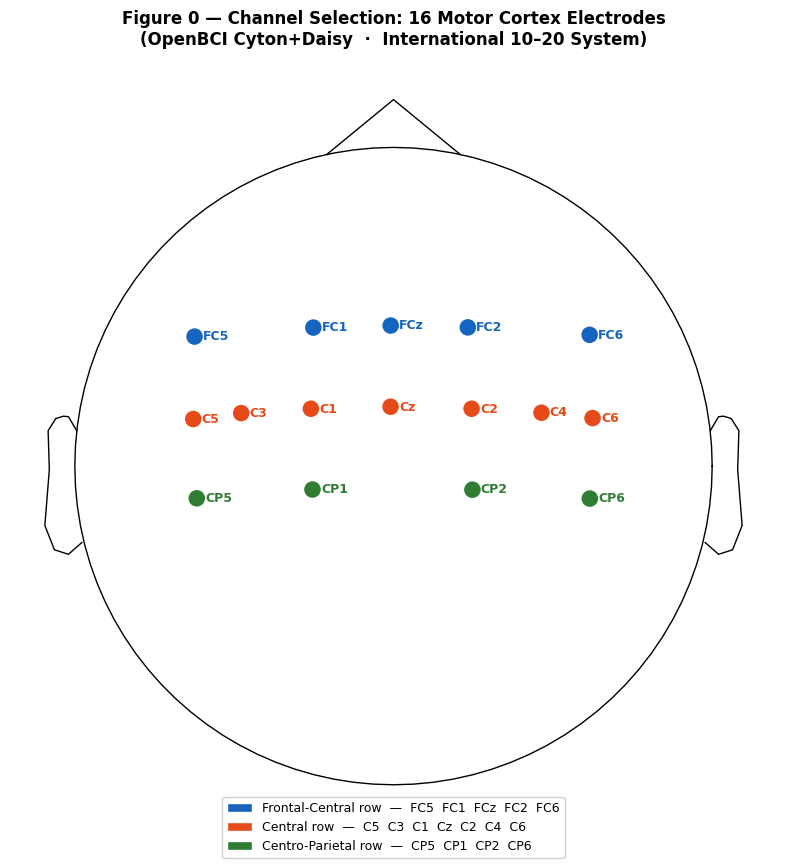

Saved: figures/00_channel_selection.png


In [32]:
import mne
from matplotlib.patches import Patch

# Build MNE Info with the 16-channel motor cortex montage
info = mne.create_info(ch_names=HW_CHANS, sfreq=FS, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

# Color by anatomical row
def _ch_color(name):
    if name.startswith('FC'):  return '#1565C0'   # blue  — frontal-central
    if name.startswith('CP'):  return '#2E7D32'   # green — centro-parietal
    return '#E64A19'                               # orange — central

colors = [_ch_color(ch) for ch in HW_CHANS]

# Draw with MNE (head outline + 10-20 projected positions)
fig = mne.viz.plot_sensors(info, show_names=True, show=False, kind='topomap',
                            title='')
ax = fig.axes[0]
fig.set_size_inches(8, 9)

# Override marker colors and sizes
for coll in ax.collections:
    try:
        n = len(coll.get_offsets())
        if n == len(HW_CHANS):
            coll.set_facecolors(colors)
            coll.set_edgecolors('white')
            coll.set_linewidths(1.5)
            coll.set_sizes([180] * n)
    except Exception:
        pass

# Color text labels to match
text_objs = [t for t in ax.texts if t.get_text() in HW_CHANS]
for text in text_objs:
    text.set_color(_ch_color(text.get_text()))
    text.set_fontweight('bold')
    text.set_fontsize(9)

# Legend
ax.legend(handles=[
    Patch(facecolor='#1565C0', edgecolor='white',
          label='Frontal-Central row  —  FC5  FC1  FCz  FC2  FC6'),
    Patch(facecolor='#E64A19', edgecolor='white',
          label='Central row  —  C5  C3  C1  Cz  C2  C4  C6'),
    Patch(facecolor='#2E7D32', edgecolor='white',
          label='Centro-Parietal row  —  CP5  CP1  CP2  CP6'),
], loc='lower center', bbox_to_anchor=(0.5, -0.06),
   fontsize=9, framealpha=0.9)

ax.set_title('Figure 0 — Channel Selection: 16 Motor Cortex Electrodes\n'
             '(OpenBCI Cyton+Daisy  ·  International 10–20 System)',
             fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
fig.savefig('figures/00_channel_selection.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/00_channel_selection.png')

## Figure 1 — Raw EEG Power Spectral Density per Class
Welch PSD averaged over **all trials and all 16 channels** for each class, before any preprocessing.  
Shows the characteristic 1/f noise shape of raw EEG and any visible differences between classes in the mu (8–13 Hz) and beta (13–30 Hz) motor imagery bands.

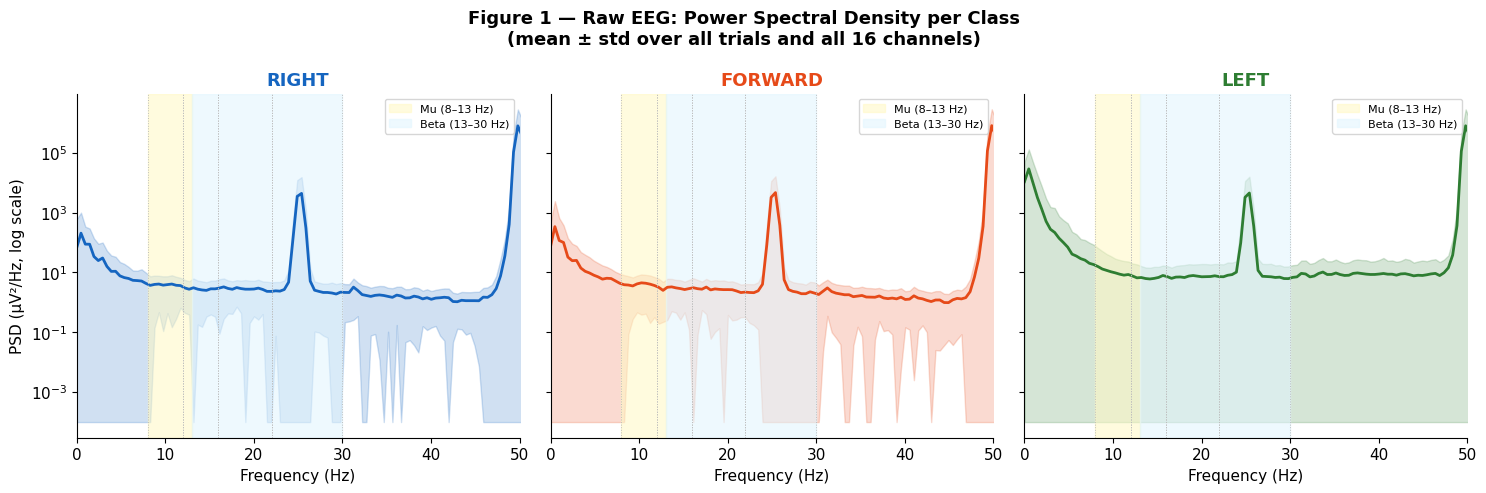

Saved: figures/01_raw_eeg_signals.png


In [33]:
fig, axes = plt.subplots(1, n_classes, figsize=(5*n_classes, 5), sharey=True)
if n_classes == 1:
    axes = [axes]

for ci, (cname, ax) in enumerate(zip(class_names, axes)):
    trials = X_raw[y == ci]           # (n_ci, 16, 500)
    psds   = []
    for trial in trials:
        for ch_sig in trial:
            f, pxx = welch(ch_sig.astype(np.float64), fs=FS, nperseg=256)
            psds.append(pxx)
    psd_mean = np.mean(psds, axis=0)
    psd_std  = np.std(psds,  axis=0)

    ax.semilogy(f, psd_mean, color=CMAP[ci], lw=2)
    ax.fill_between(f,
                    np.maximum(psd_mean - psd_std, 1e-4),
                    psd_mean + psd_std,
                    color=CMAP[ci], alpha=0.2)
    ax.axvspan(8,  13, color='#FFF9C4', alpha=0.55, label='Mu (8–13 Hz)')
    ax.axvspan(13, 30, color='#E1F5FE', alpha=0.55, label='Beta (13–30 Hz)')
    for lo, hi in BANDS:
        ax.axvline(lo, color='#BDBDBD', lw=0.7, ls=':')
        ax.axvline(hi, color='#BDBDBD', lw=0.7, ls=':')
    ax.set_title(cname.upper(), color=CMAP[ci], fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(0, 50)
    ax.legend(fontsize=8)

axes[0].set_ylabel('PSD (µV²/Hz, log scale)')
fig.suptitle('Figure 1 — Raw EEG: Power Spectral Density per Class\n'
             '(mean ± std over all trials and all 16 channels)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/01_raw_eeg_signals.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/01_raw_eeg_signals.png')

## Figure 2 — Per-Channel Band Power (Signal Quality)
Average power in the motor imagery band (8–30 Hz) per channel, per class.  
Shows which electrodes carry the most relevant signal energy before any preprocessing.

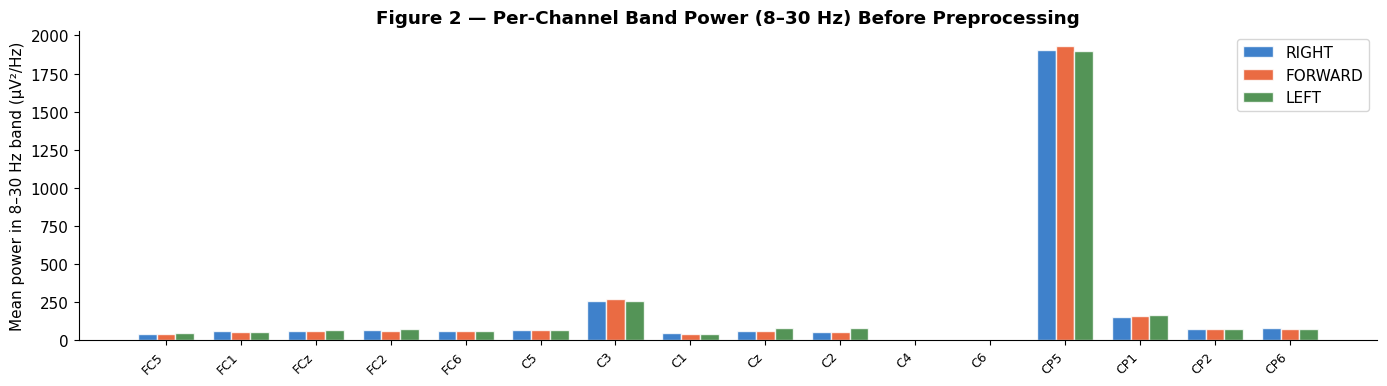

Saved: figures/02_channel_rms.png


In [34]:
# Compute average band power in 8–30 Hz per channel per class (using Welch PSD)
band_power = np.zeros((n_classes, n_ch))
for ci in range(n_classes):
    trials = X_raw[y == ci]
    for ch in range(n_ch):
        psds = []
        for trial in trials:
            f, pxx = welch(trial[ch].astype(np.float64), fs=FS, nperseg=256)
            mask   = (f >= 8) & (f <= 30)
            psds.append(np.mean(pxx[mask]))
        band_power[ci, ch] = np.mean(psds)

x     = np.arange(n_ch)
width = 0.25

fig, ax = plt.subplots(figsize=(14, 4))
for ci, cname in enumerate(class_names):
    ax.bar(x + ci*width, band_power[ci], width, label=cname.upper(),
           color=CMAP[ci], alpha=0.82, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(HW_CHANS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean power in 8–30 Hz band (µV²/Hz)')
ax.set_title('Figure 2 — Per-Channel Band Power (8–30 Hz) Before Preprocessing',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/02_channel_rms.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/02_channel_rms.png')

## Figure 3 — Common Average Reference (CAR): PSD Before vs After
PSD comparison on selected channels for one trial, showing the effect of CAR in the frequency domain.  
CAR suppresses broadband common-mode noise (visible as a drop across all frequencies) while preserving localised neural activity.

In [35]:
X_car            = apply_car_masked_batch(X_raw, bad_idx)
X_good, kept_idx = drop_bad(X_car, bad_idx)
kept_names       = [HW_CHANS[i] for i in kept_idx]

print(f'After CAR + channel drop:')
print(f'  X_good shape  : {X_good.shape}')
print(f'  Kept channels : {kept_names}')

After CAR + channel drop:
  X_good shape  : (90, 12, 500)
  Kept channels : ['FC5', 'FC1', 'FCz', 'FC2', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'CP2', 'CP6']


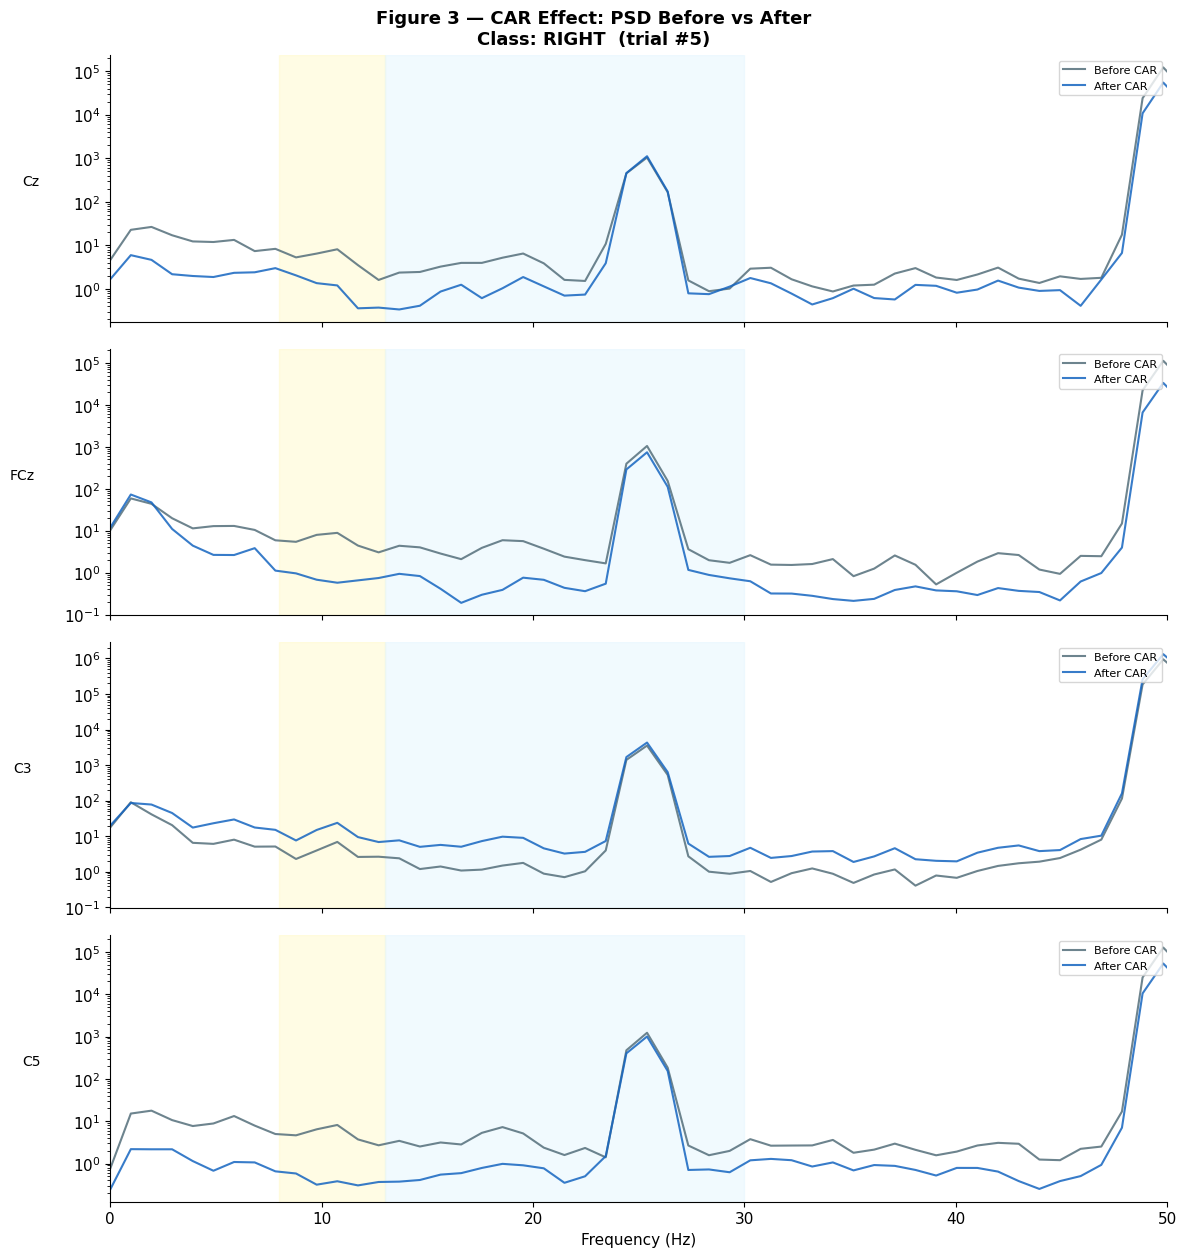

Saved: figures/03_before_after_car.png


In [36]:
show_chans = [c for c in ['Cz', 'FCz', 'C3', 'C5', 'CP1'] if c in kept_names][:4]

trial_idx = np.where(y == 0)[0][min(2, int((y==0).sum())-1)]
trial_raw = X_raw[trial_idx]
trial_car = X_car[trial_idx]

fig, axes = plt.subplots(len(show_chans), 1,
                         figsize=(12, 3.2*len(show_chans)), sharex=True)
title_str = ('Figure 3 — CAR Effect: PSD Before vs After\n'
             f'Class: {class_names[0].upper()}  (trial #{trial_idx})')
fig.suptitle(title_str, fontsize=13, fontweight='bold')

for row, ch_name in enumerate(show_chans):
    ch_idx = HW_CHANS.index(ch_name)
    ax     = axes[row]

    f_r, pxx_r = welch(trial_raw[ch_idx].astype(np.float64), fs=FS, nperseg=128)
    f_c, pxx_c = welch(trial_car[ch_idx].astype(np.float64), fs=FS, nperseg=128)

    ax.semilogy(f_r, pxx_r, color='#546E7A', lw=1.5, alpha=0.85, label='Before CAR')
    ax.semilogy(f_c, pxx_c, color='#1565C0', lw=1.5, alpha=0.85, label='After CAR')
    ax.axvspan(8,  13, color='#FFF9C4', alpha=0.45)
    ax.axvspan(13, 30, color='#E1F5FE', alpha=0.45)
    ax.set_ylabel(ch_name, rotation=0, labelpad=30, fontsize=10)
    ax.set_xlim(0, 50)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.savefig('figures/03_before_after_car.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/03_before_after_car.png')

## Figure 4 — Power Spectral Density
Welch PSD averaged over all trials and good channels per class, after CAR and before filtering.  
Mu (8–13 Hz) and beta (13–30 Hz) bands highlighted. Vertical dotted lines show filter bank boundaries.

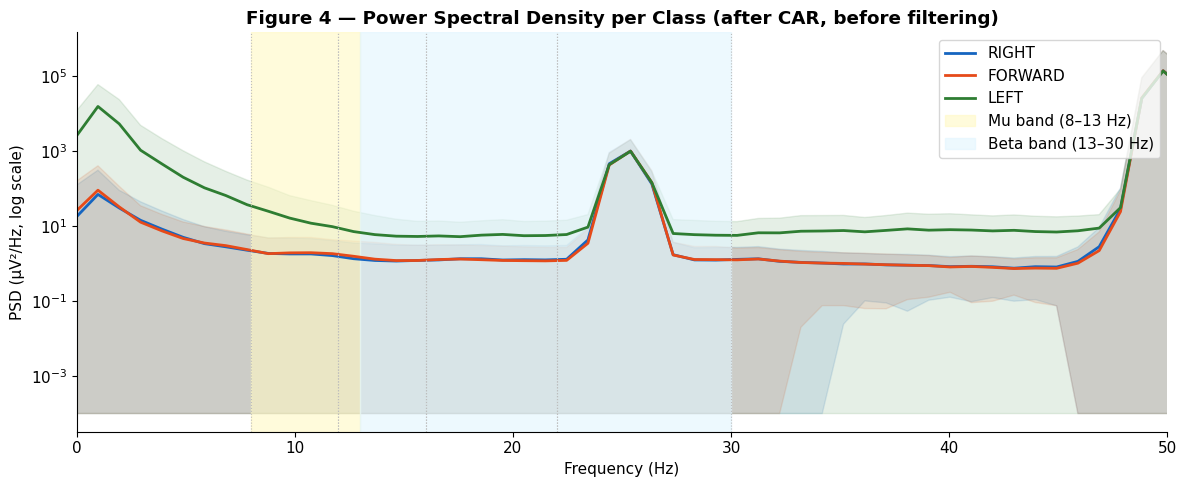

Saved: figures/04_psd_per_class.png


In [37]:
fig, ax = plt.subplots(figsize=(12, 5))

for ci, cname in enumerate(class_names):
    trials = X_good[y == ci]
    psds   = []
    for trial in trials:
        for ch_sig in trial:
            f, pxx = welch(ch_sig.astype(np.float64), fs=FS, nperseg=128)
            psds.append(pxx)
    psd_mean = np.mean(psds, axis=0)
    psd_std  = np.std(psds,  axis=0)
    ax.semilogy(f, psd_mean, color=CMAP[ci], lw=2, label=cname.upper())
    ax.fill_between(f,
                    np.maximum(psd_mean - psd_std, 1e-4),
                    psd_mean + psd_std,
                    color=CMAP[ci], alpha=0.12)

ax.axvspan(8,  13, color='#FFF9C4', alpha=0.6, label='Mu band (8–13 Hz)')
ax.axvspan(13, 30, color='#E1F5FE', alpha=0.6, label='Beta band (13–30 Hz)')
for lo, hi in BANDS:
    ax.axvline(lo, color='#BDBDBD', lw=0.8, ls=':')
    ax.axvline(hi, color='#BDBDBD', lw=0.8, ls=':')

ax.set_xlim(0, 50)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (µV²/Hz, log scale)')
ax.set_title('Figure 4 — Power Spectral Density per Class'
             ' (after CAR, before filtering)', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/04_psd_per_class.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/04_psd_per_class.png')

## Figure 5 — Filter Bank Decomposition
**Left column:** time-domain signal after each sub-band filter (one trial, channel Cz).  
**Right column:** PSD of that filtered signal — shows exactly which frequencies passed through and confirms the filter worked correctly. The grey dashed lines mark the passband edges.

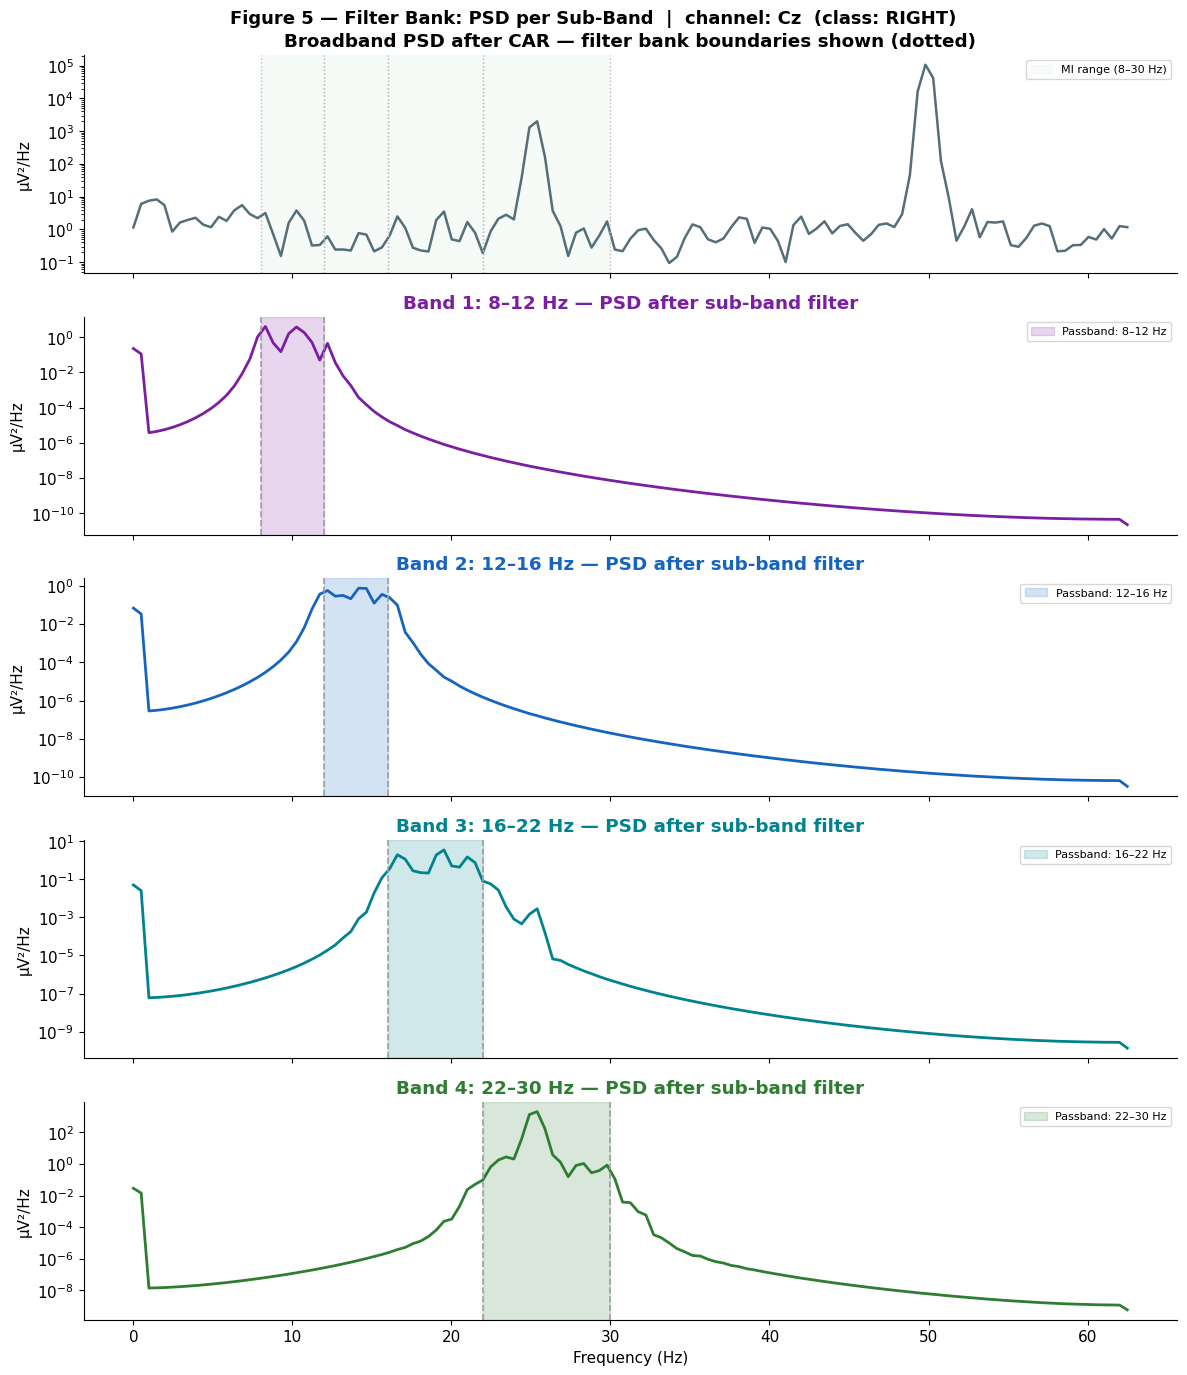

Saved: figures/05_filter_bank.png


In [38]:
ref_ch     = 'Cz' if 'Cz' in kept_names else kept_names[0]
ref_kept_i = kept_names.index(ref_ch)

trial_i    = np.where(y == 0)[0][min(2, int((y==0).sum())-1)]
good_trial = X_good[trial_i]
raw_sig    = good_trial[ref_kept_i]

band_sigs   = [bandpass(good_trial, lo, hi)[ref_kept_i] for lo, hi in BANDS]
band_labels = [f'{lo}–{hi} Hz' for lo, hi in BANDS]
band_colors = ['#7B1FA2', '#1565C0', '#00838F', '#2E7D32']

n_rows = len(BANDS) + 1
fig, axes = plt.subplots(n_rows, 1, figsize=(12, 2.8*n_rows), sharex=True)
fig.suptitle(f'Figure 5 — Filter Bank: PSD per Sub-Band  |  channel: {ref_ch}  '
             f'(class: {class_names[0].upper()})',
             fontsize=13, fontweight='bold')

# Row 0: broadband PSD with all filter bank edges marked
f0, pxx0 = welch(raw_sig.astype(np.float64), fs=FS, nperseg=256)
axes[0].semilogy(f0, pxx0, color='#546E7A', lw=1.8)
axes[0].axvspan(8, 30, color='#E8F5E9', alpha=0.35, label='MI range (8–30 Hz)')
for lo, hi in BANDS:
    axes[0].axvline(lo, color='#BDBDBD', lw=1.0, ls=':')
    axes[0].axvline(hi, color='#BDBDBD', lw=1.0, ls=':')
axes[0].set_title(f'Broadband PSD after CAR — filter bank boundaries shown (dotted)',
                  fontweight='bold')
axes[0].set_ylabel('µV²/Hz')
axes[0].legend(fontsize=8)

# Rows 1–4: one PSD per sub-band
for i, (bsig, blabel, bcolor, (lo, hi)) in enumerate(
        zip(band_sigs, band_labels, band_colors, BANDS)):

    f_b, pxx_b = welch(bsig.astype(np.float64), fs=FS, nperseg=256)
    ax = axes[i + 1]
    ax.semilogy(f_b, pxx_b, color=bcolor, lw=2)
    ax.axvspan(lo, hi, color=bcolor, alpha=0.18, label=f'Passband: {blabel}')
    ax.axvline(lo, color='#9E9E9E', lw=1.2, ls='--')
    ax.axvline(hi, color='#9E9E9E', lw=1.2, ls='--')
    ax.set_title(f'Band {i+1}: {blabel} — PSD after sub-band filter',
                 color=bcolor, fontweight='bold')
    ax.set_ylabel('µV²/Hz')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.savefig('figures/05_filter_bank.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/05_filter_bank.png')

## Figure 6 — Log-Variance per Band per Class
Log-variance of the band-filtered signal averaged over kept channels, shown as a box plot per class.  
This is the raw feature before CSP; class separability visible here confirms the filter bank is capturing discriminative information.

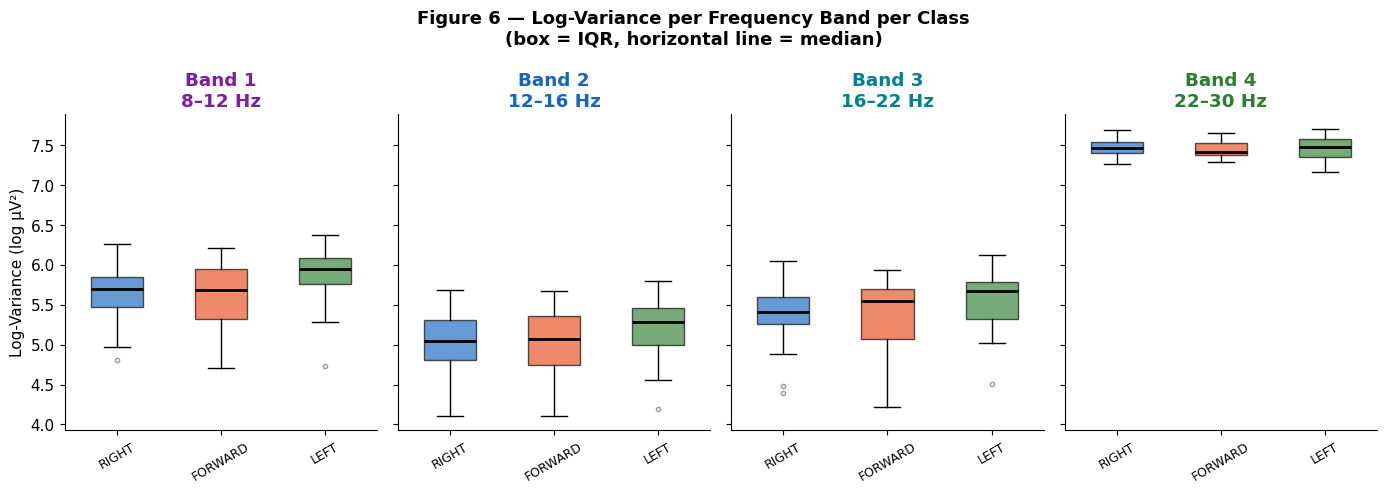

Saved: figures/06_band_power_per_class.png


In [39]:
logvar = np.zeros((n_trials, len(BANDS)))
for ti in range(n_trials):
    trial = X_good[ti]
    for bi, (lo, hi) in enumerate(BANDS):
        filtered      = bandpass(trial, lo, hi)
        logvar[ti, bi] = np.log(np.var(filtered) + 1e-9)

band_labels = [f'{lo}\u2013{hi} Hz' for lo, hi in BANDS]
band_colors = ['#7B1FA2', '#1565C0', '#00838F', '#2E7D32']

fig, axes = plt.subplots(1, len(BANDS), figsize=(14, 5), sharey=True)
for bi, (ax, blabel, bcolor) in enumerate(zip(axes, band_labels, band_colors)):
    for ci, cname in enumerate(class_names):
        vals = logvar[y == ci, bi]
        ax.boxplot(vals, positions=[ci], widths=0.5,
                   patch_artist=True,
                   boxprops=dict(facecolor=CMAP[ci], alpha=0.65),
                   medianprops=dict(color='black', lw=2),
                   flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels([c.upper() for c in class_names], rotation=30, fontsize=9)
    ax.set_title(f'Band {bi+1}\n{blabel}', color=bcolor, fontweight='bold')

axes[0].set_ylabel('Log-Variance (log µV²)')
fig.suptitle('Figure 6 — Log-Variance per Frequency Band per Class\n'
             '(box = IQR, horizontal line = median)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/06_band_power_per_class.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/06_band_power_per_class.png')

## Figures 7 & 8 — FBCSP Feature Space and CSP Spatial Patterns
Fit the full FBCSP pipeline on all data (for visualisation; cross-validated accuracy is in Figure 9).

In [40]:
print('Fitting FBCSP on all data (for visualisation only) ...')
fbcsp = FBCSPExtractor()
fbcsp.fit(X_good, y)
F = fbcsp.transform(X_good)    # (n_trials, n_features)
print(f'Feature matrix: {F.shape}  (n_trials x n_features)')
print(f'  {len(BANDS)} bands x {N_CSP} CSP components = {F.shape[1]} features')

Fitting FBCSP on all data (for visualisation only) ...
Computing rank from data with rank=None
    Using tolerance 31 (2.2e-16 eps * 12 dim * 1.2e+16  max singular value)
    Estimated rank (data): 12
    data: rank 12 computed from 12 data channels with 0 projectors
Reducing data rank from 12 -> 12
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 23 (2.2e-16 eps * 12 dim * 8.6e+15  max singular value)
    Estimated rank (data): 12
    data: rank 12 computed from 12 data channels with 0 projectors
Reducing data rank from 12 -> 12
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 28 (2.2e-16 eps * 12 dim * 1e+16  max singular value)
    Estimated r

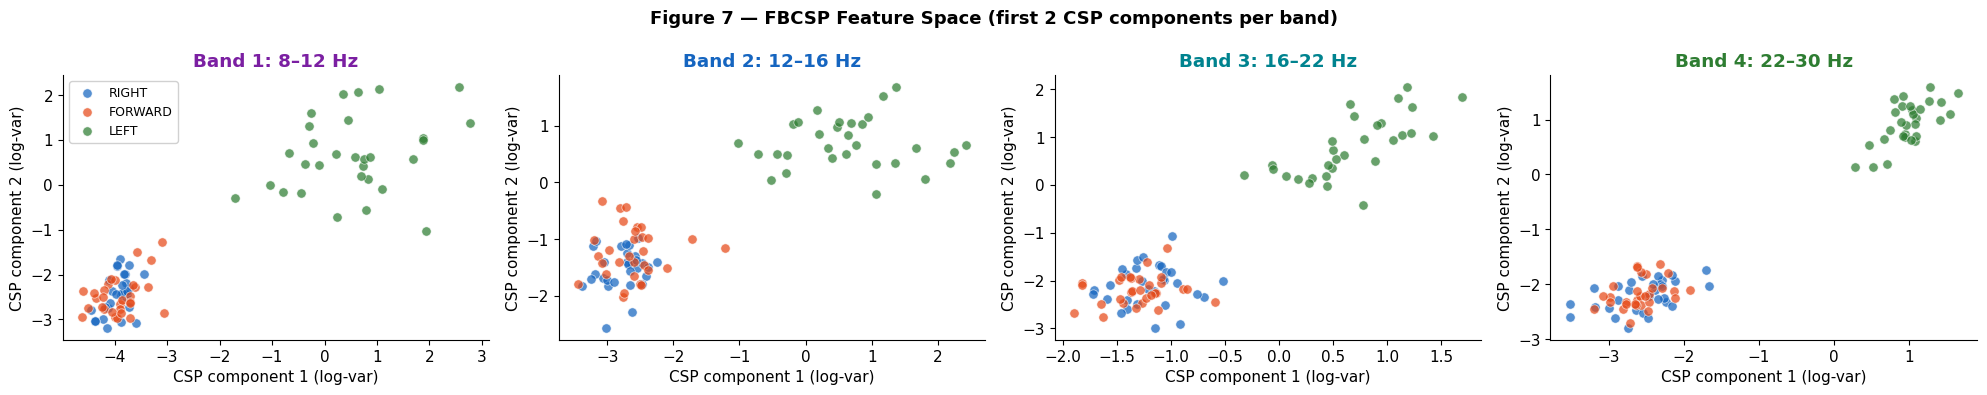

Saved: figures/07_fbcsp_feature_scatter.png


In [45]:
band_labels = [f'{lo}\u2013{hi} Hz' for lo, hi in BANDS]
band_colors = ['#7B1FA2', '#1565C0', '#00838F', '#2E7D32']

fig, axes = plt.subplots(1, len(BANDS), figsize=(5*len(BANDS), 4))
for bi, (ax, blabel, bcolor) in enumerate(zip(axes, band_labels, band_colors)):
    foff = bi * N_CSP
    for ci, cname in enumerate(class_names):
        mask = (y == ci)
        ax.scatter(F[mask, foff], F[mask, foff + 1],
                   c=CMAP[ci], label=cname.upper(),
                   alpha=0.72, s=45, edgecolors='white', lw=0.5)
    ax.set_xlabel('CSP component 1 (log-var)')
    ax.set_ylabel('CSP component 2 (log-var)')
    ax.set_title(f'Band {bi+1}: {blabel}', color=bcolor, fontweight='bold')
    if bi == 0:
        ax.legend(fontsize=9, framealpha=0.9)

fig.suptitle('Figure 7 — FBCSP Feature Space (first 2 CSP components per band)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/07_fbcsp_feature_scatter.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/07_fbcsp_feature_scatter.png')

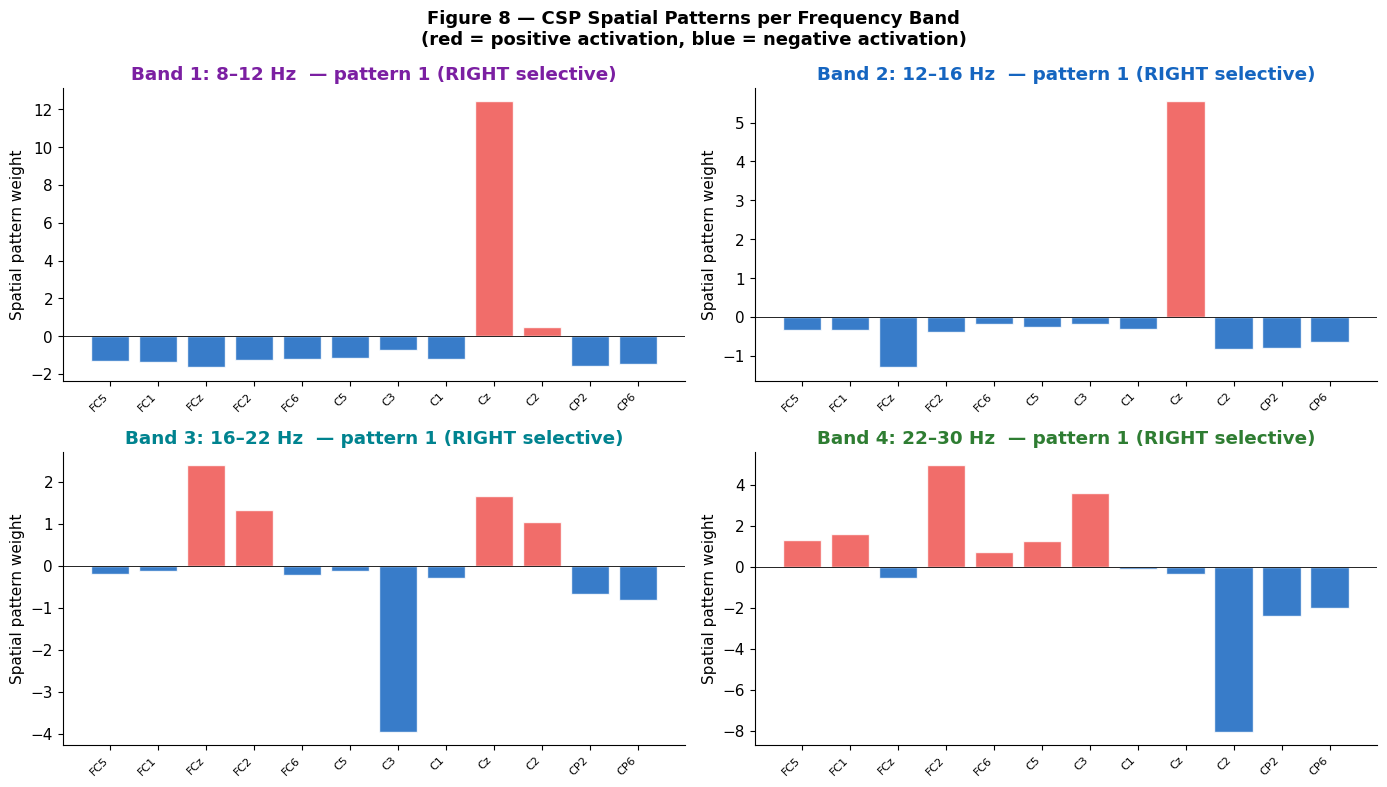

Saved: figures/08_csp_spatial_patterns.png


In [42]:
band_labels = [f'{lo}\u2013{hi} Hz' for lo, hi in BANDS]
band_colors = ['#7B1FA2', '#1565C0', '#00838F', '#2E7D32']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for bi, (ax, blabel, bcolor) in enumerate(zip(axes, band_labels, band_colors)):
    csp     = fbcsp.csps[bi]
    pattern = csp.patterns_[0]   # most class-0-selective spatial pattern
    colors  = ['#EF5350' if v > 0 else '#1565C0' for v in pattern]
    ax.bar(range(len(kept_names)), pattern, color=colors, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(kept_names)))
    ax.set_xticklabels(kept_names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Spatial pattern weight')
    title_str = (f'Band {bi+1}: {blabel}  '
                 f'\u2014 pattern 1 ({class_names[0].upper()} selective)')
    ax.set_title(title_str, color=bcolor, fontweight='bold')
    ax.axhline(0, color='black', lw=0.6)

fig.suptitle('Figure 8 — CSP Spatial Patterns per Frequency Band\n'
             '(red = positive activation, blue = negative activation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/08_csp_spatial_patterns.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/08_csp_spatial_patterns.png')

## Figure 9 — Cross-Validation Results
5-fold stratified cross-validation with FBCSP + LDA. Confusion matrix shown as raw counts and as recall (normalised by true class).

Computing rank from data with rank=None
    Using tolerance 28 (2.2e-16 eps * 12 dim * 1e+16  max singular value)
    Estimated rank (data): 12
    data: rank 12 computed from 12 data channels with 0 projectors
Reducing data rank from 12 -> 12
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 21 (2.2e-16 eps * 12 dim * 7.7e+15  max singular value)
    Estimated rank (data): 12
    data: rank 12 computed from 12 data channels with 0 projectors
Reducing data rank from 12 -> 12
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 25 (2.2e-16 eps * 12 dim * 9.2e+15  max singular value)
    Estimated rank (data): 12
    data: rank 12 computed from 12 data 

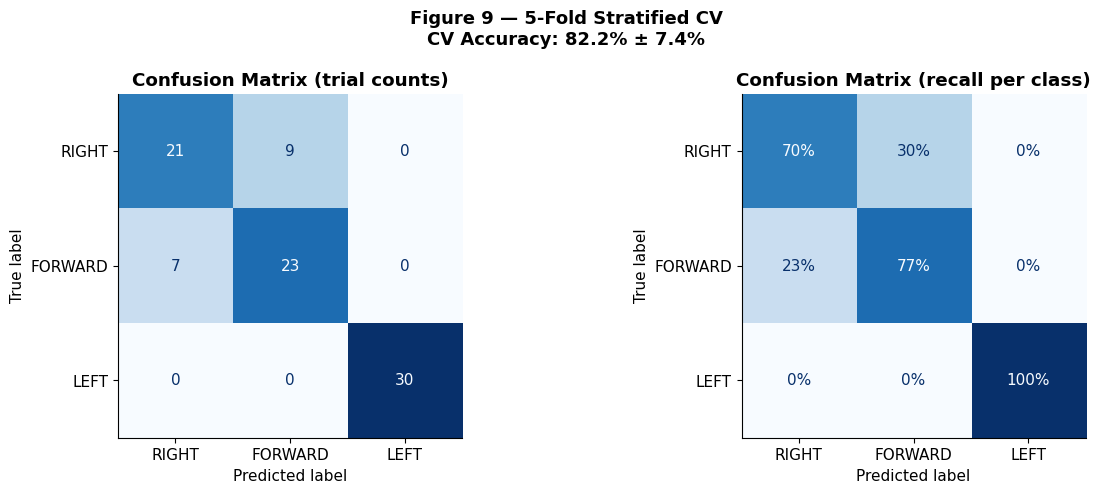

Saved: figures/09_confusion_matrix.png


In [43]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
all_pred, all_true, fold_accs = [], [], []

for fold, (tr, te) in enumerate(skf.split(X_good, y), 1):
    fb  = FBCSPExtractor()
    fb.fit(X_good[tr], y[tr])
    Ftr = fb.transform(X_good[tr])
    Fte = fb.transform(X_good[te])
    clf = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
    clf.fit(Ftr, y[tr])
    pred = clf.predict(Fte)
    acc  = float((pred == y[te]).mean())
    fold_accs.append(acc)
    all_pred.extend(pred)
    all_true.extend(y[te])
    print(f'  Fold {fold}: {acc:.1%}')

cv_mean = float(np.mean(fold_accs))
cv_std  = float(np.std(fold_accs))
print(f'\nCV Accuracy: {cv_mean:.1%} \u00b1 {cv_std:.1%}')

cm      = confusion_matrix(all_true, all_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
labels  = [c.upper() for c in class_names]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (trial counts)', fontweight='bold')

ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.0%')
axes[1].set_title('Confusion Matrix (recall per class)', fontweight='bold')

fig.suptitle(f'Figure 9 \u2014 5-Fold Stratified CV\nCV Accuracy: {cv_mean:.1%} \u00b1 {cv_std:.1%}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/09_confusion_matrix.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/09_confusion_matrix.png')

## Figure 10 — Full Pipeline Summary: Frequency Domain View
Each column shows the PSD at a different preprocessing stage for one trial per class (channel Cz).  
**Raw PSD → After CAR → After 8–12 Hz filter → FBCSP features**

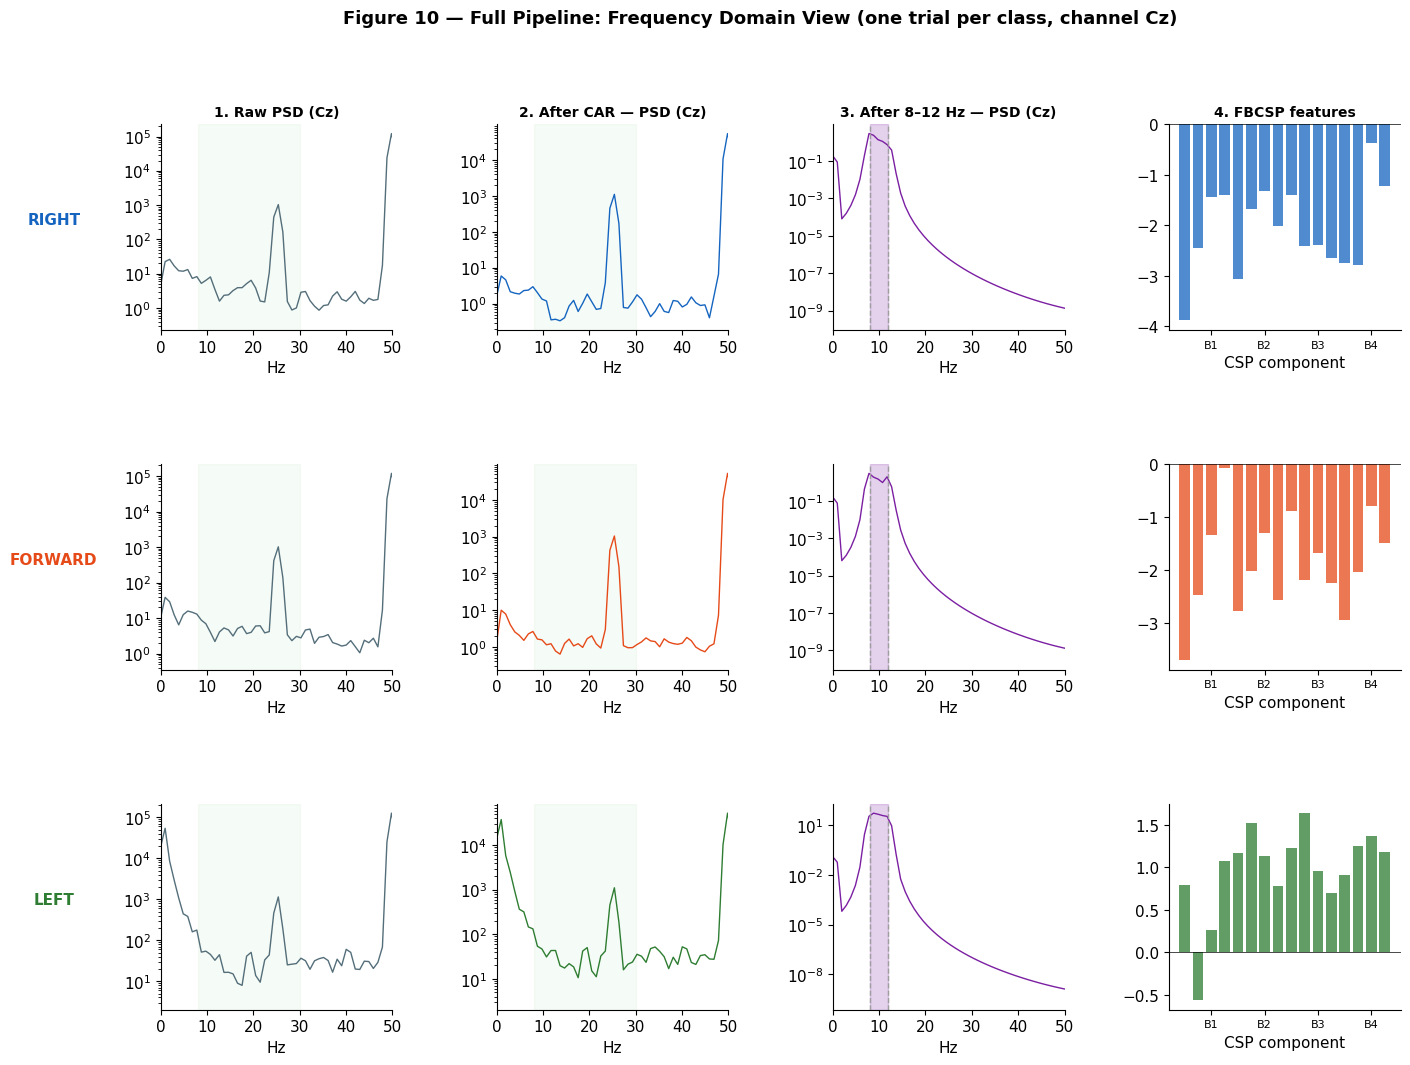

Saved: figures/10_pipeline_summary.png


In [44]:
cz_hw_i   = HW_CHANS.index('Cz')
cz_kept_i = kept_names.index('Cz') if 'Cz' in kept_names else 0

col_titles = ['1. Raw PSD (Cz)', '2. After CAR — PSD (Cz)',
              '3. After 8–12 Hz — PSD (Cz)', '4. FBCSP features']

fig = plt.figure(figsize=(16, 3.5 * n_classes + 1))
gs  = gridspec.GridSpec(n_classes, 4, figure=fig, hspace=0.65, wspace=0.45)

lo0, hi0 = BANDS[0]

for ci, cname in enumerate(class_names):
    ti         = np.where(y == ci)[0][min(2, int((y==ci).sum())-1)]
    raw_trial  = X_raw[ti]
    car_trial  = X_car[ti]
    good_trial = X_good[ti]
    feats      = F[ti]

    # PSD at each preprocessing stage (channel Cz)
    f_r, pxx_r = welch(raw_trial[cz_hw_i].astype(np.float64),  fs=FS, nperseg=128)
    f_c, pxx_c = welch(car_trial[cz_hw_i].astype(np.float64),  fs=FS, nperseg=128)
    cz_filt    = bandpass(good_trial, lo0, hi0)[cz_kept_i]
    f_f, pxx_f = welch(cz_filt.astype(np.float64),             fs=FS, nperseg=128)

    # Col 1: raw PSD
    ax = fig.add_subplot(gs[ci, 0])
    ax.semilogy(f_r, pxx_r, color='#546E7A', lw=1)
    ax.axvspan(8, 30, color='#E8F5E9', alpha=0.4)
    ax.set_ylabel(cname.upper(), color=CMAP[ci],
                  fontweight='bold', rotation=0, labelpad=50)
    ax.set_xlabel('Hz');  ax.set_xlim(0, 50)
    if ci == 0: ax.set_title(col_titles[0], fontsize=10, fontweight='bold')

    # Col 2: after CAR PSD
    ax = fig.add_subplot(gs[ci, 1])
    ax.semilogy(f_c, pxx_c, color=CMAP[ci], lw=1)
    ax.axvspan(8, 30, color='#E8F5E9', alpha=0.4)
    ax.set_xlabel('Hz');  ax.set_xlim(0, 50)
    if ci == 0: ax.set_title(col_titles[1], fontsize=10, fontweight='bold')

    # Col 3: after 8-12 Hz band filter PSD
    ax = fig.add_subplot(gs[ci, 2])
    ax.semilogy(f_f, pxx_f, color='#7B1FA2', lw=1)
    ax.axvspan(lo0, hi0, color='#7B1FA2', alpha=0.2)
    ax.axvline(lo0, color='#9E9E9E', lw=1, ls='--')
    ax.axvline(hi0, color='#9E9E9E', lw=1, ls='--')
    ax.set_xlabel('Hz');  ax.set_xlim(0, 50)
    if ci == 0: ax.set_title(col_titles[2], fontsize=10, fontweight='bold')

    # Col 4: FBCSP feature vector (log-variance bar chart)
    ax = fig.add_subplot(gs[ci, 3])
    ax.bar(range(len(feats)), feats, color=CMAP[ci], alpha=0.75, width=0.8)
    ax.axhline(0, color='black', lw=0.5)
    mid = N_CSP // 2
    ax.set_xticks([bi*N_CSP + mid for bi in range(len(BANDS))])
    ax.set_xticklabels([f'B{bi+1}' for bi in range(len(BANDS))], fontsize=8)
    ax.set_xlabel('CSP component')
    if ci == 0: ax.set_title(col_titles[3], fontsize=10, fontweight='bold')

fig.suptitle('Figure 10 — Full Pipeline: Frequency Domain View (one trial per class, channel Cz)',
             fontsize=13, fontweight='bold')
plt.savefig('figures/10_pipeline_summary.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/10_pipeline_summary.png')

---
## Summary

All 11 figures saved to `figures/` at 200 DPI.

| File | Description |
|---|---|
| `figures/00_channel_selection.png` | 16 electrode positions on head diagram (10–20 system) |
| `figures/01_raw_eeg_signals.png` | Raw EEG PSD per class — before any preprocessing |
| `figures/02_channel_rms.png` | Per-channel band power (8–30 Hz) before preprocessing |
| `figures/03_before_after_car.png` | CAR effect: PSD before vs after |
| `figures/04_psd_per_class.png` | Welch PSD per class with mu/beta bands highlighted |
| `figures/05_filter_bank.png` | Filter bank decomposition (4 sub-bands) |
| `figures/06_band_power_per_class.png` | Log-variance box plots per band per class |
| `figures/07_fbcsp_feature_scatter.png` | 2D scatter of first 2 CSP components per band |
| `figures/08_csp_spatial_patterns.png` | CSP spatial patterns across electrodes |
| `figures/09_confusion_matrix.png` | 5-fold CV confusion matrix (counts + recall) |
| `figures/10_pipeline_summary.png` | Full pipeline — raw → CAR → filter → features |